In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score

In [2]:
# load the breast cancer dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Task 3.1 - basic structure
print("Observations:", X.shape[0])
print("Features:", X.shape[1])
print("Classes:", np.unique(y), "->", data.target_names)
print(pd.DataFrame(X, columns=data.feature_names).head())

# Task 3.2 - 80/20 split, stratified, same random_state throughout
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train:", X_train.shape, "Test:", X_test.shape)

Observations: 569
Features: 30
Classes: [0 1] -> ['malignant' 'benign']
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dime

In [3]:
# single tree as the baseline
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

dt_train_acc = accuracy_score(y_train, dt.predict(X_train))
dt_test_acc  = accuracy_score(y_test,  dt.predict(X_test))

print("Decision Tree - train:", dt_train_acc, "test:", dt_test_acc)

Decision Tree - train: 1.0 test: 0.9122807017543859


In [4]:
# random forest with 100 trees
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

rf_train_acc = accuracy_score(y_train, rf.predict(X_train))
rf_test_acc  = accuracy_score(y_test,  rf.predict(X_test))

print("Random Forest - train:", rf_train_acc, "test:", rf_test_acc)

Random Forest - train: 1.0 test: 0.956140350877193


1 trees -> test acc: 0.9474
5 trees -> test acc: 0.9386
10 trees -> test acc: 0.9386
50 trees -> test acc: 0.9561
100 trees -> test acc: 0.9561
200 trees -> test acc: 0.9561


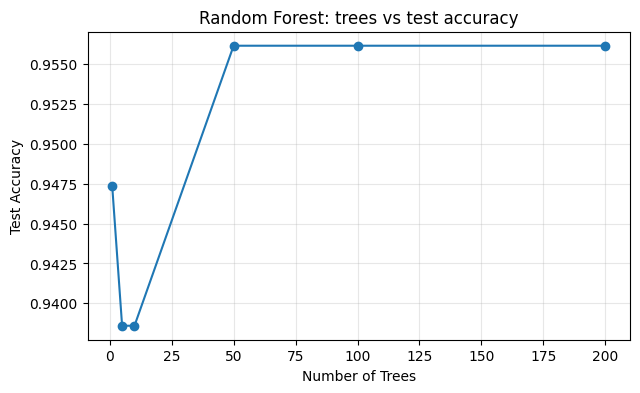

In [5]:
# Task 6.1 - test different numbers of trees
tree_counts = [1, 5, 10, 50, 100, 200]
tree_acc = []

for n in tree_counts:
    m = RandomForestClassifier(n_estimators=n, random_state=42)
    m.fit(X_train, y_train)
    acc = accuracy_score(y_test, m.predict(X_test))
    tree_acc.append(acc)
    print(n, "trees -> test acc:", round(acc, 4))

# Task 6.2 - line graph
plt.figure(figsize=(7,4))
plt.plot(tree_counts, tree_acc, marker='o')
plt.xlabel("Number of Trees")
plt.ylabel("Test Accuracy")
plt.title("Random Forest: trees vs test accuracy")
plt.grid(alpha=0.3)
plt.show()

In [6]:
# depth controls how complex each tree gets
depths = [2, 4, 6, 10, None]

for d in depths:
    m = RandomForestClassifier(n_estimators=100, max_depth=d, random_state=42)
    m.fit(X_train, y_train)
    tr = accuracy_score(y_train, m.predict(X_train))
    te = accuracy_score(y_test,  m.predict(X_test))
    print("max_depth =", d, "| train:", round(tr,4), "| test:", round(te,4))

max_depth = 2 | train: 0.9648 | test: 0.9474
max_depth = 4 | train: 0.9934 | test: 0.9561
max_depth = 6 | train: 0.9956 | test: 0.9474
max_depth = 10 | train: 1.0 | test: 0.9561
max_depth = None | train: 1.0 | test: 0.9561


In [7]:
# max_features = how many features each split is allowed to look at
for f in [2, 5, 10, "sqrt", "log2"]:
    m = RandomForestClassifier(n_estimators=100, max_features=f, random_state=42)
    m.fit(X_train, y_train)
    te = accuracy_score(y_test, m.predict(X_test))
    print("max_features =", f, "| test:", round(te, 4))

max_features = 2 | test: 0.9561
max_features = 5 | test: 0.9561
max_features = 10 | test: 0.9561
max_features = sqrt | test: 0.9561
max_features = log2 | test: 0.9561


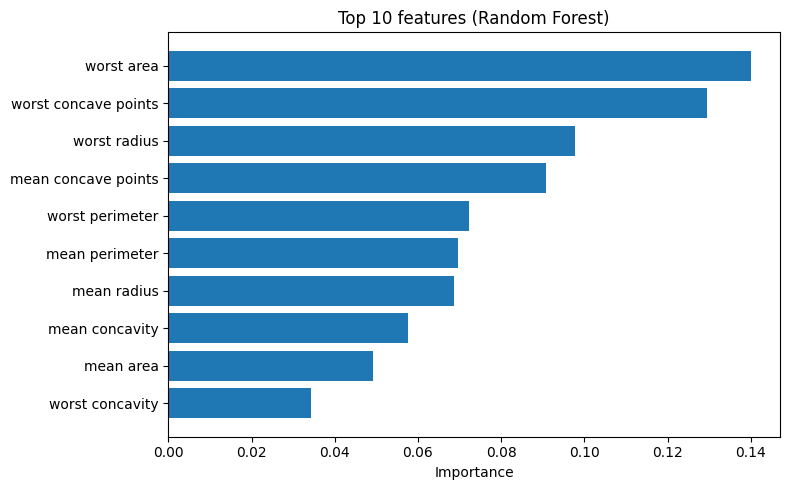

Run 1 top 10: [np.str_('worst area'), np.str_('worst concave points'), np.str_('worst radius'), np.str_('mean concave points'), np.str_('worst perimeter'), np.str_('mean perimeter'), np.str_('mean radius'), np.str_('mean concavity'), np.str_('mean area'), np.str_('worst concavity')]
Run 2 top 10: [np.str_('worst radius'), np.str_('worst concave points'), np.str_('worst perimeter'), np.str_('worst area'), np.str_('mean concave points'), np.str_('mean perimeter'), np.str_('worst concavity'), np.str_('mean area'), np.str_('mean radius'), np.str_('mean concavity')]


In [8]:
# which features the forest relied on most
importances = rf.feature_importances_
order = np.argsort(importances)[::-1][:10]

plt.figure(figsize=(8,5))
plt.barh([data.feature_names[i] for i in order][::-1], importances[order][::-1])
plt.xlabel("Importance")
plt.title("Top 10 features (Random Forest)")
plt.tight_layout()
plt.show()

# repeat with a different random_state to see if the top features stay the same
rf2 = RandomForestClassifier(n_estimators=100, random_state=7).fit(X_train, y_train)
order2 = np.argsort(rf2.feature_importances_)[::-1][:10]
print("Run 1 top 10:", [data.feature_names[i] for i in order])
print("Run 2 top 10:", [data.feature_names[i] for i in order2])

In [9]:
# Task 9.1 - residuals
y_actual = np.array([60, 70, 80])
y_pred   = np.array([55, 72, 74])
print("Residuals:", y_actual - y_pred)

# Task 10.1 and 10.2 - gradient boosting update F_m = F_{m-1} + eta * h
prev, h = 60, 10
print("eta = 0.1 ->", prev + 0.1 * h)
print("eta = 1.0 ->", prev + 1.0 * h)

Residuals: [ 5 -2  6]
eta = 0.1 -> 61.0
eta = 1.0 -> 70.0


In [10]:
# gradient boosting with the settings given in the lab
gb = GradientBoostingClassifier(
    n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42
)
gb.fit(X_train, y_train)

gb_train_acc = accuracy_score(y_train, gb.predict(X_train))
gb_test_acc  = accuracy_score(y_test,  gb.predict(X_test))

print("Gradient Boosting - train:", gb_train_acc, "test:", gb_test_acc)

# quick side by side of all three
print("\nModel comparison")
print("DT  train:", round(dt_train_acc,4), "test:", round(dt_test_acc,4))
print("RF  train:", round(rf_train_acc,4), "test:", round(rf_test_acc,4))
print("GB  train:", round(gb_train_acc,4), "test:", round(gb_test_acc,4))

Gradient Boosting - train: 1.0 test: 0.956140350877193

Model comparison
DT  train: 1.0 test: 0.9123
RF  train: 1.0 test: 0.9561
GB  train: 1.0 test: 0.9561


lr = 0.01 | train: 0.9868 | test: 0.9211
lr = 0.05 | train: 1.0 | test: 0.9474
lr = 0.1 | train: 1.0 | test: 0.9561
lr = 0.5 | train: 1.0 | test: 0.9561
lr = 1.0 | train: 1.0 | test: 0.9561


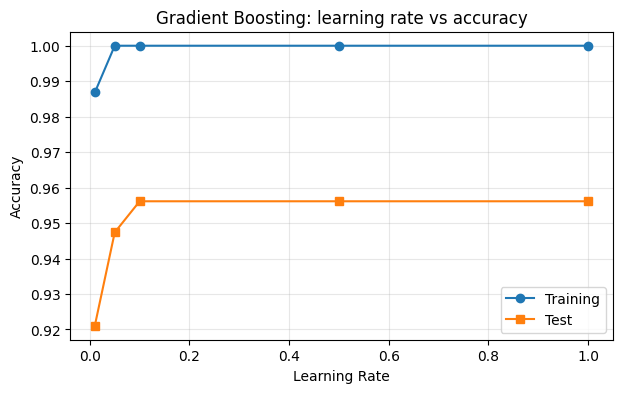

In [11]:
# Task 12.1 - how learning rate affects boosting
rates = [0.01, 0.05, 0.10, 0.50, 1.00]
gb_train, gb_test = [], []

for lr in rates:
    m = GradientBoostingClassifier(
        n_estimators=100, learning_rate=lr, max_depth=3, random_state=42
    )
    m.fit(X_train, y_train)
    tr = accuracy_score(y_train, m.predict(X_train))
    te = accuracy_score(y_test,  m.predict(X_test))
    gb_train.append(tr)
    gb_test.append(te)
    print("lr =", lr, "| train:", round(tr,4), "| test:", round(te,4))

# Task 12.2 - plot both curves
plt.figure(figsize=(7,4))
plt.plot(rates, gb_train, marker='o', label='Training')
plt.plot(rates, gb_test,  marker='s', label='Test')
plt.xlabel("Learning Rate")
plt.ylabel("Accuracy")
plt.title("Gradient Boosting: learning rate vs accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [12]:
# Q26 - 2 x 2 x 2 = 8 combinations, each run 5 times
param_grid = {
    "n_estimators":  [50, 100],
    "learning_rate": [0.05, 0.10],
    "max_depth":     [2, 3]
}

grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy"
)
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV accuracy:", round(grid.best_score_, 4))

# final check on the untouched test set
best_gb = grid.best_estimator_
print("Final test accuracy:", round(accuracy_score(y_test, best_gb.predict(X_test)), 4))

Best params: {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 100}
Best CV accuracy: 0.9648
Final test accuracy: 0.9474


In [13]:
# random search samples combinations instead of trying all of them
param_dist = {
    "n_estimators":  [50, 100, 150, 200],
    "learning_rate": [0.01, 0.05, 0.1, 0.2, 0.5],
    "max_depth":     [2, 3, 4, 5]
}

rand = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_dist,
    n_iter=10,          # only 10 random combos
    cv=5,
    scoring="accuracy",
    random_state=42
)
rand.fit(X_train, y_train)

print("Random search best params:", rand.best_params_)
print("Best CV accuracy:", round(rand.best_score_, 4))
print("Test accuracy:", round(accuracy_score(y_test, rand.predict(X_test)), 4))

# compare with the grid search results from Part I
print("\nGrid search combos:", len(grid.cv_results_['params']))
print("Random search combos:", rand.n_iter)

Random search best params: {'n_estimators': 150, 'max_depth': 3, 'learning_rate': 0.5}
Best CV accuracy: 0.9648
Test accuracy: 0.9561

Grid search combos: 8
Random search combos: 10
